In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# =====================================================
# 1. MODEL DEFINITION
# =====================================================

class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()
        
        # Encoder layers
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        
        # Decoder layers
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        """Pass input through encoder to get mu and log variance."""
        h1 = F.relu(self.fc1(x))
        return self.fc_mu(h1), self.fc_logvar(h1)

    def reparameterize(self, mu, logvar):
        """Sample z from the latent distribution."""
        std = torch.exp(0.5 * logvar) # Convert log variance to standard deviation
        eps = torch.randn_like(std)   # Sample from standard normal
        return mu + eps * std

    def decode(self, z):
        """Pass latent vector z through decoder to reconstruct image."""
        h3 = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h3)) # Sigmoid pushes pixel values to [0, 1]

    def forward(self, x):
        # Flatten the image: (batch_size, 1, 28, 28) -> (batch_size, 784)
        x_flat = x.view(-1, 784)
        mu, logvar = self.encode(x_flat)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar

# =====================================================
# 2. LOSS FUNCTION
# =====================================================

def vae_loss(recon_x, x, mu, logvar):
    """
    VAE loss combines Reconstruction Loss (Binary Cross Entropy) 
    and Kullback-Leibler Divergence (KLD).
    """
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

# =====================================================
# 3. TRAINING LOOP
# =====================================================

def train_vae(epochs=50, batch_size=256, learning_rate=1e-4):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Training on device: {device}")

    # Load MNIST Dataset
    transform = transforms.ToTensor()
    train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # Initialize Model and Optimizer
    model = VAE().to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Training iterations
    model.train()
    for epoch in range(1, epochs + 1):
        train_loss = 0
        for batch_idx, (data, _) in enumerate(train_loader):
            data = data.to(device)
            
            optimizer.zero_grad()
            recon_batch, mu, logvar = model(data)
            loss = vae_loss(recon_batch, data, mu, logvar)
            
            loss.backward()
            train_loss += loss.item()
            optimizer.step()
                
        print(f"====> Epoch: {epoch} Average loss: {train_loss / len(train_loader.dataset):.4f}")

    return model, train_dataset, device

# =====================================================
# 4. LATENT CENTROID GENERATION
# =====================================================

def generate_specific_digit(model, dataset, target_digit=0, num_variations=5, device="cpu"):
    """
    Finds the latent centroid of a specific digit and samples around it 
    to generate novel variations.
    """
    model.eval()
    
    # Gather real images of the target digit
    images = []
    for img, label in dataset:
        if label == target_digit:
            images.append(img)
            if len(images) == 100: # Take 100 samples to find a stable average
                break
                
    images_tensor = torch.stack(images).to(device)
    
    with torch.no_grad():
        # Encode to find latent distributions
        x_flat = images_tensor.view(-1, 784)
        mu, logvar = model.encode(x_flat)
        
        # Calculate the "centroid" (average coordinate)
        latent_centroid = mu.mean(dim=0)
        
        # Sample around the centroid with a little noise for variety
        noise = torch.randn(num_variations, 20).to(device) * 0.25
        z_samples = latent_centroid.unsqueeze(0) + noise
        
        # Decode these coordinates back into images
        generated_images = model.decode(z_samples).view(-1, 28, 28).cpu()
        
    return generated_images

In [2]:
# 1. Train the model
trained_model, mnist_dataset, compute_device = train_vae(epochs=50)

Training on device: cpu
====> Epoch: 1 Average loss: 307.7138
====> Epoch: 2 Average loss: 208.4140
====> Epoch: 3 Average loss: 179.5702
====> Epoch: 4 Average loss: 165.3104
====> Epoch: 5 Average loss: 155.9405
====> Epoch: 6 Average loss: 148.4029
====> Epoch: 7 Average loss: 143.1477
====> Epoch: 8 Average loss: 139.2048
====> Epoch: 9 Average loss: 135.5778
====> Epoch: 10 Average loss: 132.4684
====> Epoch: 11 Average loss: 129.8056
====> Epoch: 12 Average loss: 127.6291
====> Epoch: 13 Average loss: 125.7434
====> Epoch: 14 Average loss: 124.1582
====> Epoch: 15 Average loss: 122.6614
====> Epoch: 16 Average loss: 121.3706
====> Epoch: 17 Average loss: 120.3045
====> Epoch: 18 Average loss: 119.2392
====> Epoch: 19 Average loss: 118.4249
====> Epoch: 20 Average loss: 117.7000
====> Epoch: 21 Average loss: 116.9857
====> Epoch: 22 Average loss: 116.3045
====> Epoch: 23 Average loss: 115.7383
====> Epoch: 24 Average loss: 115.1680
====> Epoch: 25 Average loss: 114.7085
====> Epoc

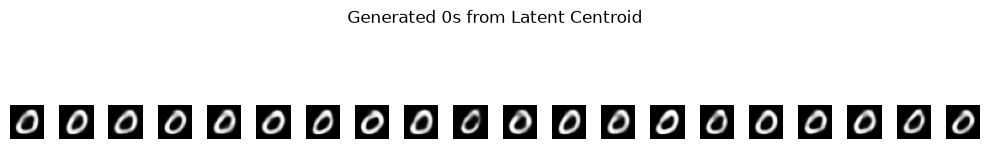

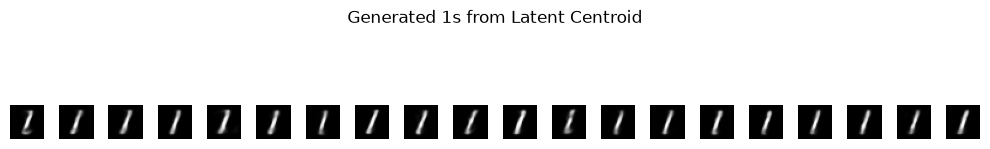

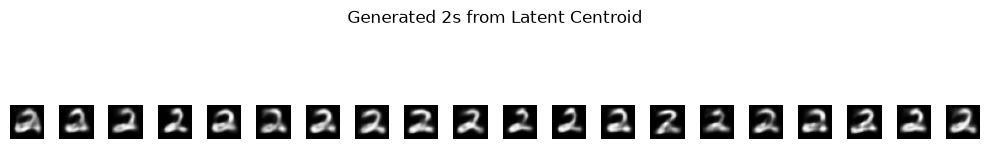

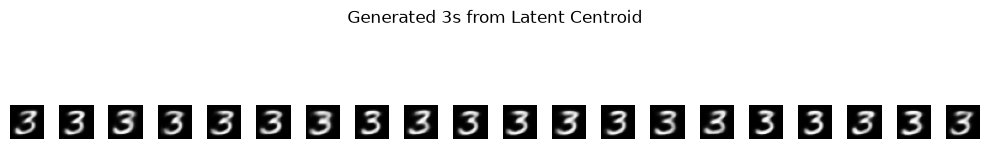

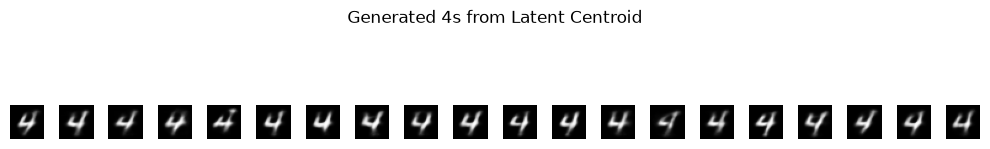

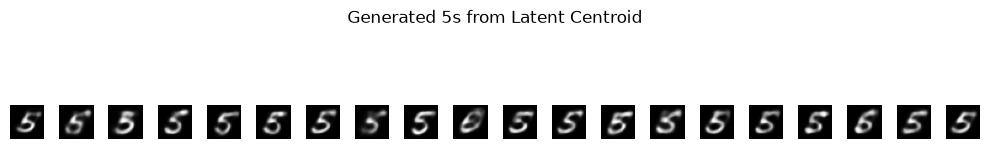

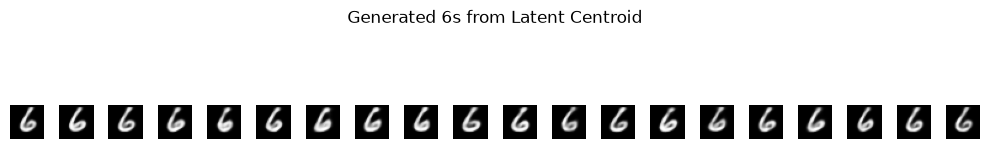

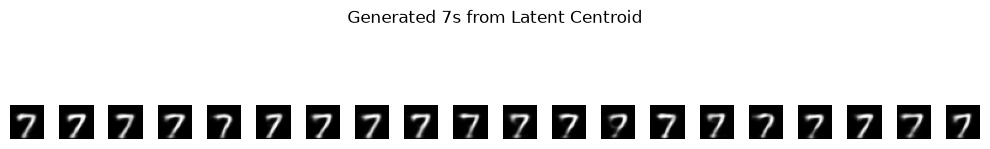

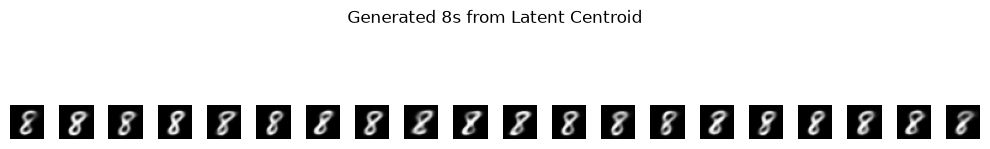

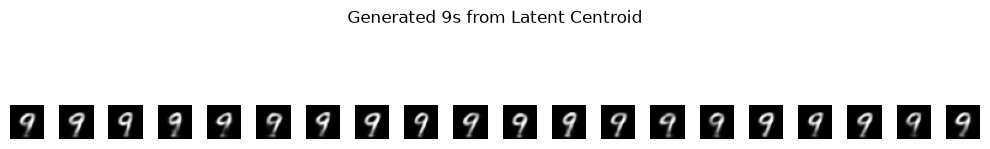

In [3]:
for nx in range(10):
    generated_zeros = generate_specific_digit(
        model=trained_model, 
        dataset=mnist_dataset, 
        target_digit=nx, 
        num_variations=20, 
        device=compute_device
    )
    
    fig, axes = plt.subplots(1, 20, figsize=(10, 2))
    for i, ax in enumerate(axes):
        ax.imshow(generated_zeros[i].numpy(), cmap='gray')
        ax.axis('off')

    plt.suptitle(f"Generated {nx}s from Latent Centroid")
    
    plt.tight_layout()
    plt.show()